[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Laverde97/phd-data-science-ai/blob/main/semesters/semester-01/machine-learning/notes/notebooks/01-arbol-decision-regresion.ipynb)


# Machine Learning: Árbol de Decisión para Regresión

## Colab completo con definiciones claras, datos reales, métricas, gráficos e interpretación

### Objetivo general

Aprender a construir, evaluar e interpretar un **Árbol de Decisión para Regresión** utilizando un conjunto de datos real.

### Al finalizar este notebook podrás:

1. Entender qué es un problema de regresión.
2. Saber qué es un Árbol de Decisión para Regresión.
3. Identificar en qué casos se utiliza.
4. Comprender cómo funciona en la vida real.
5. Preparar correctamente los datos.
6. Separar Train y Test.
7. Entrenar un `DecisionTreeRegressor`.
8. Evaluar el modelo con **MAE, MedAE, MSE, RMSE, R² y MAPE**.
9. Detectar **underfitting y overfitting**.
10. Ajustar hiperparámetros.
11. Optimizar el árbol con `GridSearchCV`.
12. Interpretar residuos, predicciones, importancia de variables y estructura del árbol.

> **Nota:** este notebook tiene fines académicos. El dataset tiene contexto médico, pero el modelo no debe utilizarse para diagnóstico ni decisiones clínicas.



# 1. ¿Qué es Machine Learning?

**Machine Learning** es una rama de la inteligencia artificial que permite construir modelos capaces de aprender patrones a partir de datos.

En lugar de programar manualmente todas las reglas, proporcionamos ejemplos históricos para que el algoritmo encuentre relaciones entre las variables.

Ejemplos de la vida real:

- predecir el precio de una vivienda;
- estimar ventas;
- predecir consumo de energía;
- estimar tiempo de entrega;
- proyectar demanda;
- estimar una variable clínica cuantitativa;
- predecir rendimiento agrícola.



# 2. ¿Qué es un problema de regresión?

La **regresión** se utiliza cuando la variable que queremos predecir es **numérica y continua**.

Tenemos:

- **X:** variables predictoras o características.
- **y:** variable objetivo.

Ejemplos:

| Problema | Variables predictoras X | Objetivo y |
|---|---|---|
| Vivienda | área, habitaciones, ubicación | precio |
| Ventas | inversión en publicidad, precio | ventas |
| Energía | temperatura, hora, ocupación | consumo |
| Agricultura | lluvia, temperatura, fertilización | rendimiento |
| Salud | variables clínicas | resultado cuantitativo |

Si la variable objetivo fuera una categoría, como `"Sí"` / `"No"`, estaríamos ante un problema de **clasificación**, no de regresión.



# 3. ¿Qué es un Árbol de Decisión para Regresión?

Un **Árbol de Decisión para Regresión** divide los datos mediante reglas sucesivas.

Por ejemplo:

`¿bmi <= 27.5?`

Dependiendo de la respuesta, una observación sigue una rama diferente.

El proceso continúa hasta llegar a una **hoja**, donde el árbol devuelve una predicción numérica.

## Partes principales

### Nodo raíz
Es la primera división del árbol.

### Nodo interno
Representa una nueva regla de decisión.

### Rama
Representa el resultado de una regla.

### Hoja
Es el nodo final y contiene la predicción.

---

## ¿Para qué se utiliza?

Los árboles de regresión son útiles cuando:

- existen relaciones no lineales;
- queremos capturar interacciones entre variables;
- necesitamos un modelo fácil de visualizar;
- queremos explicar reglas de decisión;
- no queremos asumir una relación lineal.

---

## Ventajas

- fáciles de interpretar;
- capturan relaciones no lineales;
- detectan interacciones;
- requieren poca preparación de datos;
- no necesitan normalización obligatoria;
- permiten visualizar las decisiones.

## Desventajas

- pueden sobreajustarse;
- pequeñas variaciones en los datos pueden cambiar el árbol;
- un árbol individual suele ser menos estable que Random Forest o Gradient Boosting.



# 4. Dataset real: Diabetes de scikit-learn

Utilizaremos el dataset `load_diabetes`.

Contiene:

- **442 observaciones**
- **10 variables predictoras**
- una variable objetivo numérica

La variable objetivo representa una medida cuantitativa de progresión de la enfermedad un año después de la línea base.

Variables:

- `age`: edad.
- `sex`: sexo codificado.
- `bmi`: índice de masa corporal.
- `bp`: presión arterial promedio.
- `s1`: colesterol sérico total.
- `s2`: LDL.
- `s3`: HDL.
- `s4`: razón colesterol total / HDL.
- `s5`: medida sérica relacionada con triglicéridos.
- `s6`: glucosa.

Usaremos `scaled=False` para trabajar con valores más interpretables.

**Fuente:** scikit-learn.


In [1]:

# Librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_validate,
    GridSearchCV
)
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import (
    mean_absolute_error,
    median_absolute_error,
    mean_squared_error,
    root_mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [2]:

# Cargar dataset
diabetes = load_diabetes(as_frame=True, scaled=False)

X = diabetes.data.copy()
y = diabetes.target.copy()

df = X.copy()
df["target"] = y

print("Dimensiones del dataset:", df.shape)
display(df.head())


Dimensiones del dataset: (442, 11)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,59.0,2.0,32.1,101.0,157.0,93.2,38.0,4.0,4.8598,87.0,151.0
1,48.0,1.0,21.6,87.0,183.0,103.2,70.0,3.0,3.8918,69.0,75.0
2,72.0,2.0,30.5,93.0,156.0,93.6,41.0,4.0,4.6728,85.0,141.0
3,24.0,1.0,25.3,84.0,198.0,131.4,40.0,5.0,4.8903,89.0,206.0
4,50.0,1.0,23.0,101.0,192.0,125.4,52.0,4.0,4.2905,80.0,135.0



# 5. Exploración inicial de los datos — EDA

Antes de entrenar cualquier modelo debemos conocer los datos.

Preguntas importantes:

1. ¿Cuántas observaciones tenemos?
2. ¿Qué variables existen?
3. ¿Qué tipo de datos tienen?
4. ¿Hay valores faltantes?
5. ¿Cómo se distribuye la variable objetivo?
6. ¿Existen relaciones entre las variables?

Esta etapa se conoce como **EDA — Exploratory Data Analysis**.


In [3]:

# Información general
print("Tipos de variables:")
display(df.dtypes.to_frame("dtype"))

print("\nValores faltantes:")
display(df.isna().sum().to_frame("faltantes"))

print("\nResumen estadístico:")
display(df.describe().T)


Tipos de variables:


,dtype
age,float64
sex,float64
bmi,float64
bp,float64
s1,float64
s2,float64
s3,float64
s4,float64
s5,float64
s6,float64



Valores faltantes:


,faltantes
age,0
sex,0
bmi,0
bp,0
s1,0
s2,0
s3,0
s4,0
s5,0
s6,0



Resumen estadístico:


,count,mean,std,min,25%,50%,75%,max
age,442.0,48.518100,13.109028,19.0000,38.2500,50.00000,59.0000,79.000
sex,442.0,1.468326,0.499561,1.0000,1.0000,1.00000,2.0000,2.000
bmi,442.0,26.375792,4.418122,18.0000,23.2000,25.70000,29.2750,42.200
bp,442.0,94.647014,13.831283,62.0000,84.0000,93.00000,105.0000,133.000
s1,442.0,189.140271,34.608052,97.0000,164.2500,186.00000,209.7500,301.000
s2,442.0,115.439140,30.413081,41.6000,96.0500,113.00000,134.5000,242.400
s3,442.0,49.788462,12.934202,22.0000,40.2500,48.00000,57.7500,99.000
s4,442.0,4.070249,1.290450,2.0000,3.0000,4.00000,5.0000,9.090
s5,442.0,4.641411,0.522391,3.2581,4.2767,4.62005,4.9972,6.107
s6,442.0,91.260181,11.496335,58.0000,83.2500,91.00000,98.0000,124.000


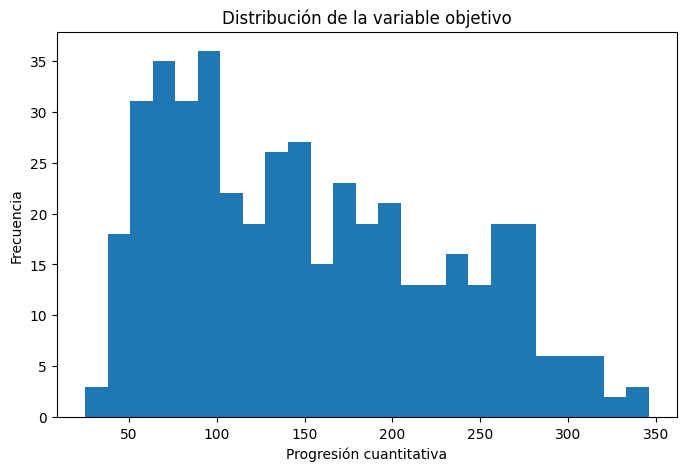

In [4]:

# Gráfico 1: distribución de la variable objetivo
plt.figure(figsize=(8, 5))
plt.hist(y, bins=25)
plt.title("Distribución de la variable objetivo")
plt.xlabel("Progresión cuantitativa")
plt.ylabel("Frecuencia")
plt.show()


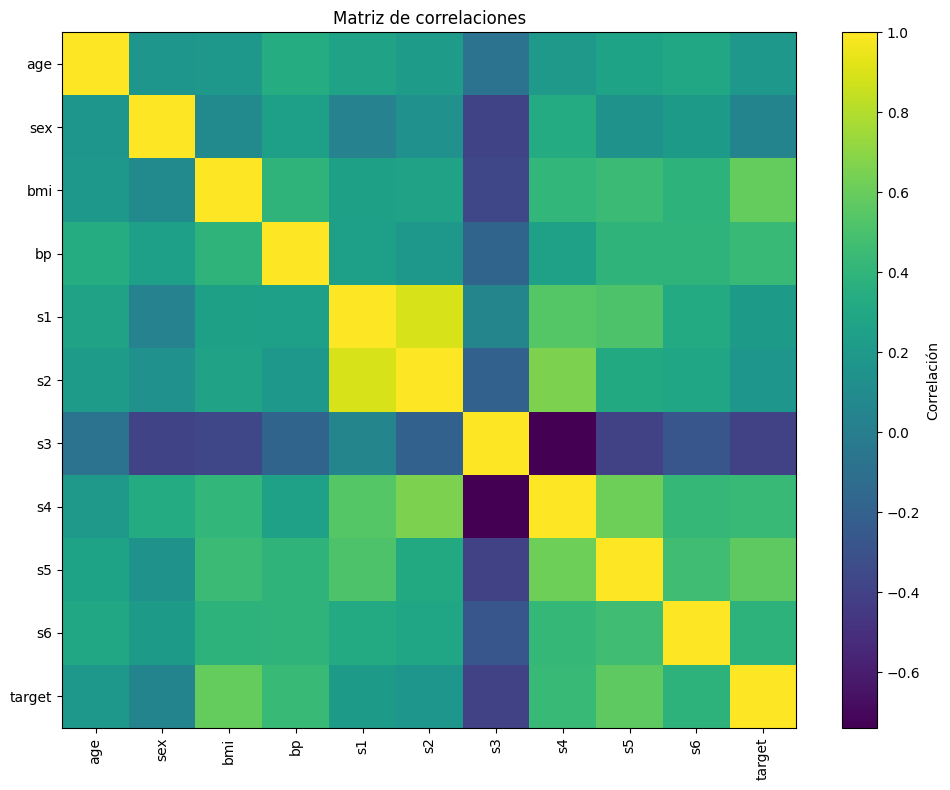

In [5]:

# Gráfico 2: matriz de correlaciones
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
img = plt.imshow(corr.values, aspect="auto")
plt.colorbar(img, label="Correlación")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Matriz de correlaciones")
plt.tight_layout()
plt.show()



# 6. Separación entre X e y

En aprendizaje supervisado debemos distinguir:

## X — Variables predictoras

Son las variables utilizadas por el modelo para aprender patrones.

## y — Variable objetivo

Es la variable que queremos predecir.

En este ejercicio:

- `X` contiene las 10 variables clínicas.
- `y` contiene la medida cuantitativa de progresión.


In [6]:

print("Variables predictoras:")
print(list(X.columns))

print("\nVariable objetivo:")
print("target")


Variables predictoras:
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

Variable objetivo:
target



# 7. División Train/Test

No debemos entrenar y evaluar el modelo con exactamente los mismos datos.

Dividiremos el dataset en:

- **Train:** datos usados para entrenar el modelo.
- **Test:** datos reservados para evaluar su capacidad de generalización.

Utilizaremos:

- 80% Train
- 20% Test

`random_state=42` permite reproducir exactamente la misma división.


In [7]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


X_train: (353, 10)
X_test : (89, 10)
y_train: (353,)
y_test : (89,)



# 8. Primer Árbol de Decisión para Regresión

Comenzaremos con un árbol relativamente controlado.

Parámetros iniciales:

- `max_depth=4`
- `min_samples_leaf=5`

Esto ayuda a reducir el riesgo de que el árbol memorice demasiado los datos.


In [8]:

modelo_baseline = DecisionTreeRegressor(
    random_state=RANDOM_STATE,
    max_depth=4,
    min_samples_leaf=5
)

modelo_baseline.fit(X_train, y_train)

pred_train_baseline = modelo_baseline.predict(X_train)
pred_test_baseline = modelo_baseline.predict(X_test)



# 9. Métricas para evaluar un modelo de regresión

Para regresión no utilizamos principalmente:

- Accuracy
- Precision
- Recall
- F1-score

Esas métricas corresponden principalmente a clasificación.

En regresión utilizamos otras métricas.



## 9.1 MAE — Mean Absolute Error

El **MAE** calcula el error absoluto promedio.

$$
MAE = \frac{1}{n}\sum |y_i-\hat{y}_i|
$$

### Interpretación

Indica, en promedio, cuánto se alejan las predicciones de los valores reales.

### ¿Cuándo es útil?

- cuando queremos una métrica fácil de interpretar;
- cuando todos los errores tienen una importancia similar;
- cuando no queremos penalizar excesivamente unos pocos errores grandes.

### Regla

**Menor MAE = mejor modelo.**



## 9.2 MedAE — Median Absolute Error

Calcula la **mediana de los errores absolutos**.

Es una métrica muy robusta frente a valores extremos.

### ¿Cuándo utilizarla?

Cuando existen observaciones con errores excepcionalmente grandes que podrían distorsionar el promedio.

### Regla

**Menor MedAE = mejor.**



## 9.3 MSE — Mean Squared Error

Promedia los errores elevados al cuadrado.

$$
MSE = \frac{1}{n}\sum(y_i-\hat{y}_i)^2
$$

### Característica principal

Los errores grandes reciben una penalización mucho mayor.

### Regla

**Menor MSE = mejor.**



## 9.4 RMSE — Root Mean Squared Error

Es la raíz cuadrada del MSE.

$$
RMSE = \sqrt{\frac{1}{n}\sum(y_i-\hat{y}_i)^2}
$$

### Ventaja

Vuelve a estar expresado en las mismas unidades de la variable objetivo.

### ¿Cuándo utilizarlo?

Cuando queremos penalizar más los errores grandes.

### Regla

**Menor RMSE = mejor.**



## 9.5 R² — Coeficiente de determinación

Indica qué tan bien el modelo explica la variabilidad del objetivo frente a utilizar siempre la media.

Interpretación general:

- `R² = 1` → ajuste perfecto.
- `R² = 0` → similar a predecir siempre la media.
- `R² < 0` → peor que ese baseline.

### Regla

**Mayor R² = mejor**, aunque nunca debe interpretarse de manera aislada.



## 9.6 MAPE — Mean Absolute Percentage Error

Expresa el error promedio en términos porcentuales.

Es intuitivo para negocio, pero tiene una limitación importante:

Si los valores reales son cercanos a cero, puede volverse inestable.

Por eso conviene acompañarlo con MAE, RMSE y R².


In [9]:

def metricas_regresion(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MedAE": median_absolute_error(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred),
        "RMSE": root_mean_squared_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
        "MAPE_%": mean_absolute_percentage_error(y_true, y_pred) * 100
    }

metricas_train_baseline = metricas_regresion(y_train, pred_train_baseline)
metricas_test_baseline = metricas_regresion(y_test, pred_test_baseline)

tabla_baseline = pd.DataFrame({
    "Train": metricas_train_baseline,
    "Test": metricas_test_baseline
}).T

display(tabla_baseline)


,MAE,MedAE,MSE,RMSE,R2,MAPE_%
Train,40.502821,33.140625,2582.766558,50.820926,0.574951,35.610505
Test,43.441655,34.140625,2997.896425,54.753049,0.434162,37.421800



# 10. ¿Qué es Underfitting?

Existe **underfitting** cuando el modelo es demasiado simple para capturar los patrones de los datos.

Señales posibles:

- error alto en Train;
- error alto en Test;
- R² bajo en ambos conjuntos.

Ejemplo:

Un árbol con profundidad 1 puede ser demasiado sencillo para un problema complejo.



# 11. ¿Qué es Overfitting?

Existe **overfitting** cuando el modelo aprende demasiado los datos de entrenamiento y pierde capacidad de generalizar.

Señales típicas:

- error muy bajo en Train;
- error considerablemente mayor en Test;
- R² muy alto en Train;
- R² mucho menor en Test.

Los árboles son especialmente propensos al overfitting cuando crecen sin restricciones.


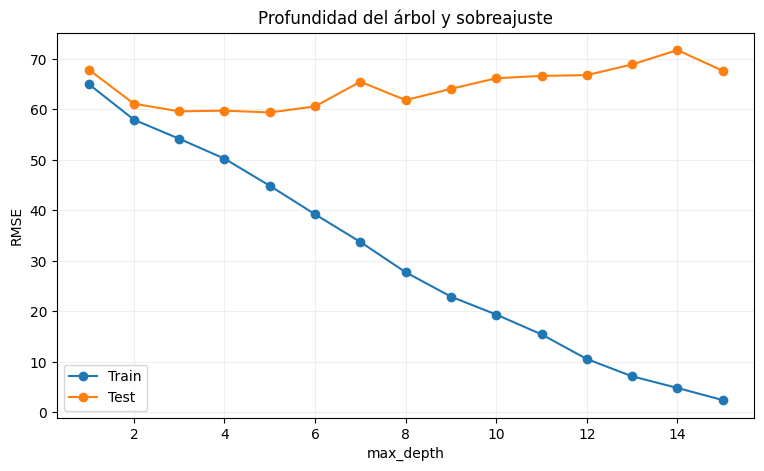

In [10]:

# Gráfico 3: profundidad vs RMSE Train/Test
profundidades = range(1, 16)

rmse_train = []
rmse_test = []

for profundidad in profundidades:

    modelo = DecisionTreeRegressor(
        random_state=RANDOM_STATE,
        max_depth=profundidad
    )

    modelo.fit(X_train, y_train)

    pred_train = modelo.predict(X_train)
    pred_test = modelo.predict(X_test)

    rmse_train.append(
        root_mean_squared_error(y_train, pred_train)
    )

    rmse_test.append(
        root_mean_squared_error(y_test, pred_test)
    )

plt.figure(figsize=(9, 5))
plt.plot(list(profundidades), rmse_train, marker="o", label="Train")
plt.plot(list(profundidades), rmse_test, marker="o", label="Test")
plt.title("Profundidad del árbol y sobreajuste")
plt.xlabel("max_depth")
plt.ylabel("RMSE")
plt.legend()
plt.grid(alpha=0.2)
plt.show()



# 12. Hiperparámetros importantes del Árbol de Regresión

## `max_depth`

Profundidad máxima.

- valores pequeños → árbol simple;
- valores muy altos → mayor riesgo de overfitting.

---

## `min_samples_split`

Número mínimo de observaciones necesarias para dividir un nodo.

Valores mayores hacen el árbol más conservador.

---

## `min_samples_leaf`

Número mínimo de observaciones permitidas en una hoja.

Puede ayudar a evitar hojas creadas con muy pocos datos.

---

## `criterion`

Define cómo se evalúa la calidad de una división.

Opciones comunes:

- `squared_error`
- `absolute_error`

---

## `max_features`

Número máximo de variables consideradas en cada división.

---

## `ccp_alpha`

Controla la **poda del árbol**.

Un valor mayor puede eliminar ramas poco útiles y reducir complejidad.



# 13. Validación cruzada

Una sola división Train/Test puede depender del azar.

La **validación cruzada** permite evaluar el modelo varias veces utilizando diferentes particiones de los datos de entrenamiento.

Usaremos **5-fold cross-validation**.

El conjunto Train se divide en 5 partes:

1. entrenamos con 4;
2. validamos con 1;
3. repetimos hasta utilizar cada parte como validación.

Esto proporciona una evaluación más estable.


In [11]:

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2"
}

resultado_cv = cross_validate(
    modelo_baseline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

resumen_cv = pd.DataFrame({
    "MAE": -resultado_cv["test_MAE"],
    "RMSE": -resultado_cv["test_RMSE"],
    "R2": resultado_cv["test_R2"]
})

display(resumen_cv)

print("\nPromedios:")
display(resumen_cv.mean().to_frame("Promedio").T)


,MAE,RMSE,R2
0,46.799598,61.592122,0.294383
1,59.065546,69.081803,0.313908
2,49.223781,64.616717,0.126052
3,55.309921,65.116651,0.272723
4,51.144643,66.065342,0.370860



Promedios:


,MAE,RMSE,R2
Promedio,52.308698,65.294527,0.275585



# 14. Optimización con GridSearchCV

`GridSearchCV` permite probar automáticamente varias combinaciones de hiperparámetros.

En lugar de escoger valores manualmente, evaluamos diferentes configuraciones mediante validación cruzada.

Optimizar únicamente con Test sería incorrecto, porque terminaríamos adaptando el modelo al conjunto de evaluación.

Utilizaremos como criterio principal:

**RMSE de validación cruzada**

porque penaliza con mayor fuerza los errores grandes y está expresado en las mismas unidades de `y`.


In [22]:

modelo_grid = DecisionTreeRegressor(
    random_state=RANDOM_STATE
)

param_grid = {
    "criterion": ["squared_error", "absolute_error"],
    "max_depth": [2, 3, 4, 5, 6, 8, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10, 15],
    "ccp_alpha": [0.0, 0.01, 0.1]
}

grid = GridSearchCV(
    estimator=modelo_grid,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

grid.fit(X_train, y_train)

print("Mejores hiperparámetros:")
print(grid.best_params_)

print("\nMejor RMSE promedio de validación cruzada:")
print(-grid.best_score_)


Mejores hiperparámetros:
{'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': 2, 'min_samples_leaf': 1, 'min_samples_split': 2}

Mejor RMSE promedio de validación cruzada:
63.047562457259176



# 15. Evaluación final del mejor modelo

Después de seleccionar los hiperparámetros usando únicamente Train + validación cruzada, evaluamos el modelo una sola vez sobre Test.

Este es el flujo correcto:

`Train → validación cruzada → selección → Test final`


In [13]:

mejor_modelo = grid.best_estimator_

pred_train_final = mejor_modelo.predict(X_train)
pred_test_final = mejor_modelo.predict(X_test)

metricas_train_final = metricas_regresion(
    y_train,
    pred_train_final
)

metricas_test_final = metricas_regresion(
    y_test,
    pred_test_final
)

tabla_final = pd.DataFrame({
    "Train": metricas_train_final,
    "Test": metricas_test_final
}).T

display(tabla_final)


,MAE,MedAE,MSE,RMSE,R2,MAPE_%
Train,47.329190,41.559211,3358.625381,57.953649,0.447267,41.979366
Test,49.365345,40.559211,3735.499618,61.118734,0.294943,45.552960


In [14]:

# Comparación Baseline vs Modelo optimizado
comparacion_modelos = pd.DataFrame({
    "Baseline": metricas_test_baseline,
    "Optimizado": metricas_test_final
}).T

display(comparacion_modelos)


,MAE,MedAE,MSE,RMSE,R2,MAPE_%
Baseline,43.441655,34.140625,2997.896425,54.753049,0.434162,37.42180
Optimizado,49.365345,40.559211,3735.499618,61.118734,0.294943,45.55296



# 16. Gráfico: valores reales vs predichos

Este gráfico compara:

- eje X: valores reales;
- eje Y: predicciones.

La línea diagonal representa predicciones perfectas.

Cuanto más cerca estén los puntos de esa línea, mejor.


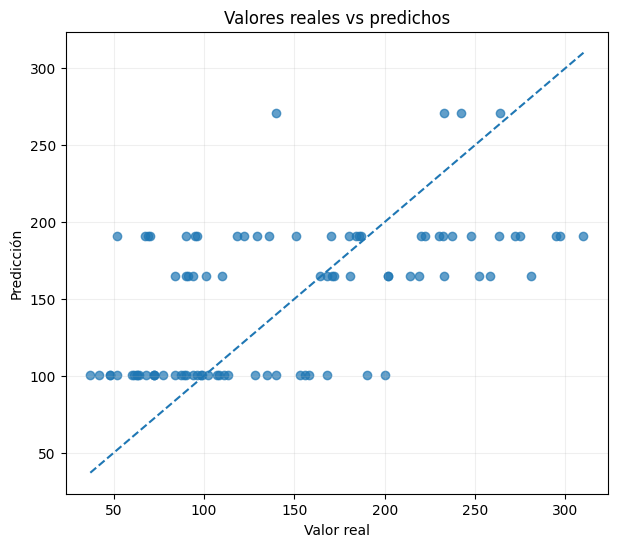

In [15]:

# Gráfico 4: Real vs Predicho
plt.figure(figsize=(7, 6))

plt.scatter(y_test, pred_test_final, alpha=0.7)

minimo = min(y_test.min(), pred_test_final.min())
maximo = max(y_test.max(), pred_test_final.max())

plt.plot(
    [minimo, maximo],
    [minimo, maximo],
    linestyle="--"
)

plt.title("Valores reales vs predichos")
plt.xlabel("Valor real")
plt.ylabel("Predicción")
plt.grid(alpha=0.2)
plt.show()



# 17. Análisis de residuos

Un **residuo** es:

$$
Residuo = Valor\ real - Predicción
$$

Interpretación:

- residuo cercano a 0 → buena predicción;
- residuo positivo → el modelo predijo demasiado bajo;
- residuo negativo → el modelo predijo demasiado alto.


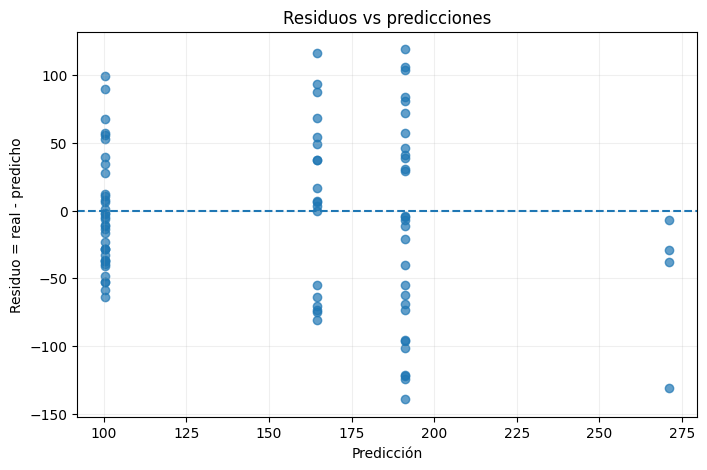

In [23]:

residuos = y_test.to_numpy() - pred_test_final

# Gráfico 5: residuos vs predicciones
plt.figure(figsize=(8, 5))
plt.scatter(pred_test_final, residuos, alpha=0.7)
plt.axhline(0, linestyle="--")

plt.title("Residuos vs predicciones")
plt.xlabel("Predicción")
plt.ylabel("Residuo = real - predicho")
plt.grid(alpha=0.2)
plt.show()



## ¿Qué buscamos?

Idealmente:

- residuos distribuidos alrededor de cero;
- sin un patrón claro;
- dispersión relativamente estable.

Si aparece una estructura evidente, puede indicar que el modelo no está capturando completamente la relación entre las variables.


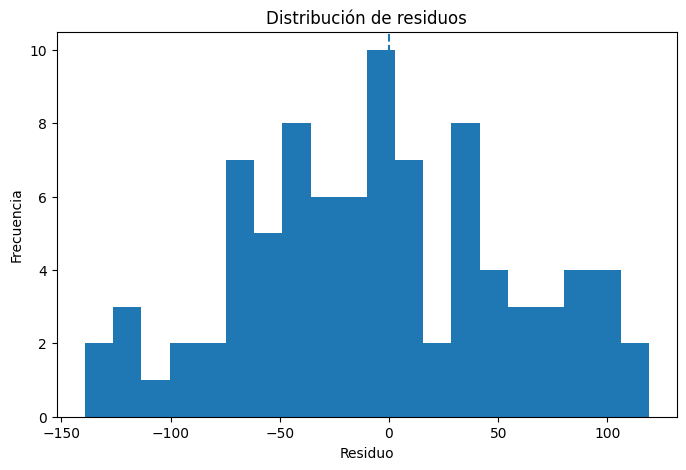

In [17]:

# Gráfico 6: distribución de residuos
plt.figure(figsize=(8, 5))
plt.hist(residuos, bins=20)
plt.axvline(0, linestyle="--")

plt.title("Distribución de residuos")
plt.xlabel("Residuo")
plt.ylabel("Frecuencia")
plt.show()



# 18. Importancia de variables

Los árboles permiten estimar qué variables fueron más utilizadas para reducir el error.

Esto se conoce como **feature importance**.

Importante:

> Una variable importante para el modelo no necesariamente es una causa del fenómeno.

La importancia es **predictiva**, no causal.


In [18]:

importancias = pd.Series(
    mejor_modelo.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

display(importancias.to_frame("Importancia"))


,Importancia
bmi,0.822417
s5,0.177583
sex,0.000000
age,0.000000
s1,0.000000
bp,0.000000
s2,0.000000
s3,0.000000
s4,0.000000
s6,0.000000


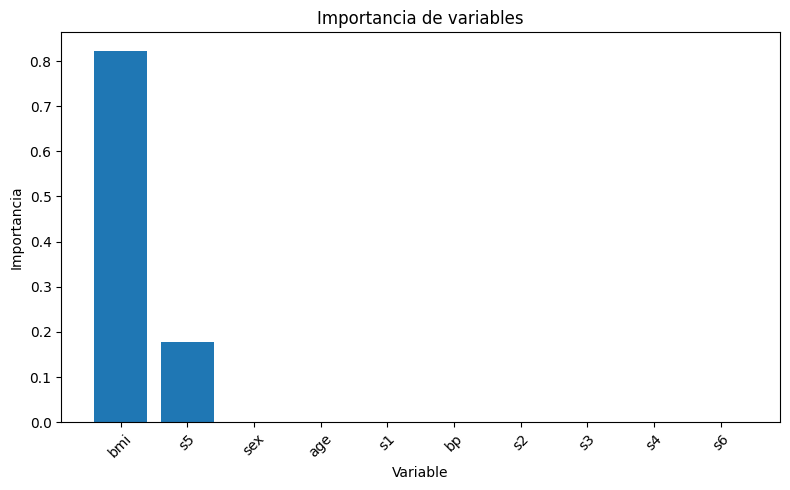

In [19]:

# Gráfico 7: importancia de variables
plt.figure(figsize=(8, 5))
plt.bar(importancias.index, importancias.values)

plt.title("Importancia de variables")
plt.xlabel("Variable")
plt.ylabel("Importancia")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



# 19. Visualización del árbol

Una de las ventajas de los árboles es que podemos visualizar las reglas utilizadas.

Mostraremos únicamente los primeros niveles para conservar la legibilidad.


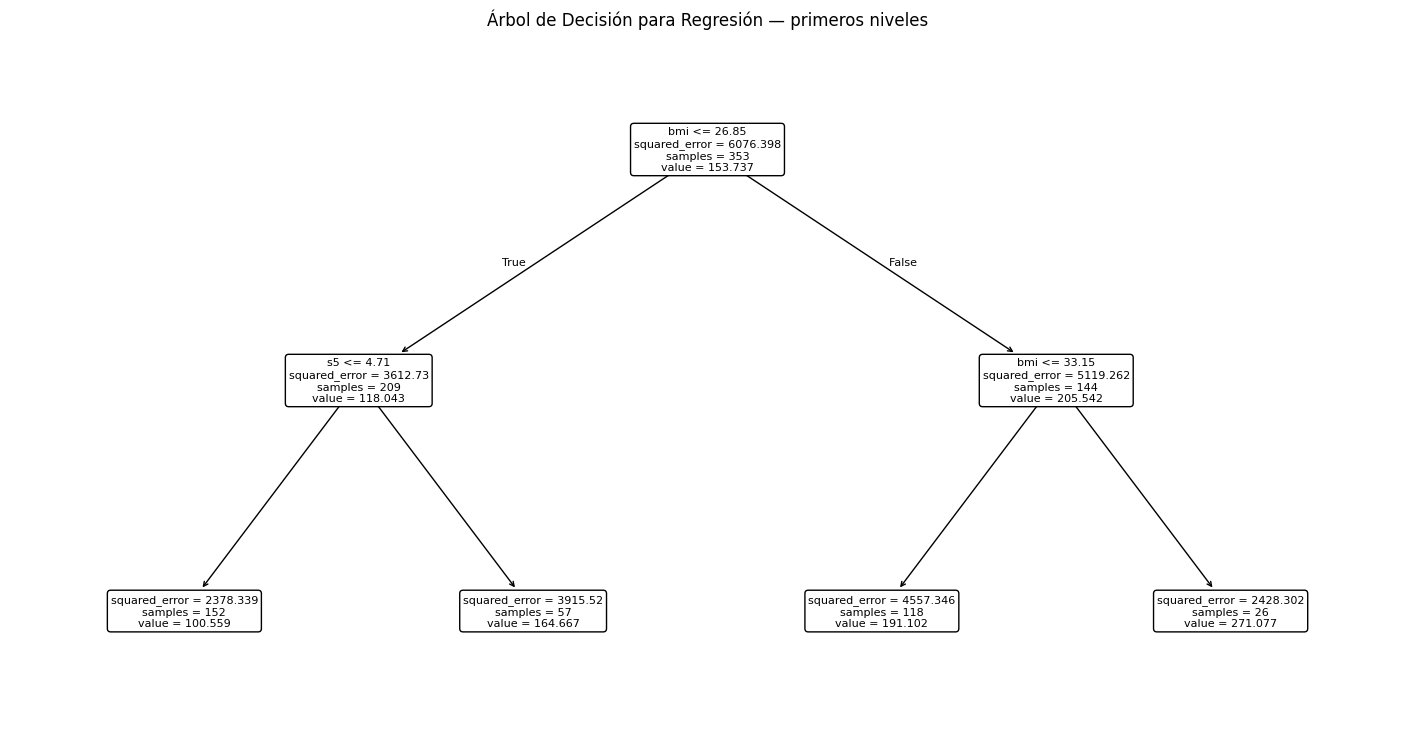

In [20]:

# Gráfico 8: estructura del árbol
plt.figure(figsize=(18, 9))

plot_tree(
    mejor_modelo,
    feature_names=X.columns,
    filled=False,
    rounded=True,
    max_depth=3,
    fontsize=8
)

plt.title("Árbol de Decisión para Regresión — primeros niveles")
plt.show()



# 20. ¿Cómo leer un nodo del árbol?

Un nodo puede mostrar información como:

- variable utilizada para dividir;
- punto de corte;
- error del nodo;
- número de observaciones;
- valor promedio utilizado para la predicción.

Ejemplo conceptual:

`bmi <= 27.5`

Si la condición es verdadera, la observación sigue una rama.

Si es falsa, sigue la otra.

El proceso continúa hasta alcanzar una hoja.



# 21. Predicción para una observación nueva

En un caso real, una vez entrenado el modelo podemos recibir una nueva observación y producir una predicción.

Aquí construiremos un perfil utilizando la mediana de las variables de entrenamiento únicamente como ejemplo académico.


In [21]:

nueva_observacion = X_train.median().to_frame().T

display(nueva_observacion)

prediccion = mejor_modelo.predict(nueva_observacion)[0]

print("Predicción del Árbol de Decisión:", round(prediccion, 2))


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,51.0,1.0,25.9,93.0,186.0,112.8,48.0,4.0,4.6347,92.0


Predicción del Árbol de Decisión: 100.56



# 22. ¿Cómo se utilizaría un Árbol de Regresión en la vida real?

## Ejemplo 1 — Vivienda

Variables:

- metros cuadrados;
- habitaciones;
- baños;
- antigüedad;
- ubicación.

Objetivo:

`Precio de venta`

---

## Ejemplo 2 — Ventas

Variables:

- inversión en publicidad;
- precio;
- promociones;
- temporada;
- tráfico web.

Objetivo:

`Ventas mensuales`

---

## Ejemplo 3 — Energía

Variables:

- temperatura;
- humedad;
- hora;
- día;
- ocupación.

Objetivo:

`Consumo energético`

---

## Ejemplo 4 — Agricultura

Variables:

- precipitación;
- temperatura;
- calidad del suelo;
- fertilizante.

Objetivo:

`Producción por hectárea`

---

## Ejemplo 5 — Logística

Variables:

- distancia;
- tráfico;
- tipo de vehículo;
- cantidad de paquetes;
- clima.

Objetivo:

`Tiempo de entrega`



# 23. ¿Cuándo conviene utilizar un Árbol de Decisión?

Puede ser una buena opción cuando:

- queremos interpretabilidad;
- existen relaciones no lineales;
- sospechamos interacciones entre variables;
- buscamos un baseline fácil de explicar;
- necesitamos reglas visuales.

Puede no ser la mejor opción cuando:

- necesitamos máxima estabilidad;
- el problema requiere gran capacidad predictiva;
- pequeños cambios en los datos modifican mucho el árbol.

En esos casos podemos evaluar métodos más avanzados como:

- Random Forest;
- Gradient Boosting;
- XGBoost;
- LightGBM;
- CatBoost.



# 24. Métricas recomendadas según el objetivo

## Si quiero una métrica fácil de explicar

**MAE**

Porque indica el error absoluto promedio en unidades del objetivo.

---

## Si existen valores extremos

**MedAE**

Porque la mediana es más robusta.

---

## Si los errores grandes son especialmente costosos

**RMSE**

Porque penaliza con mayor fuerza los errores grandes.

---

## Si quiero conocer capacidad explicativa relativa

**R²**

Pero siempre acompañado de otra métrica.

---

## Si negocio necesita una interpretación porcentual

**MAPE**

Siempre verificando que la variable objetivo no contenga valores cercanos a cero.

---

# Recomendación práctica

En muchos problemas de regresión conviene reportar al menos:

**MAE + RMSE + R²**

y, si existen outliers importantes:

**MedAE**



# 25. Errores comunes al utilizar Árboles de Regresión

## Error 1
Entrenar y evaluar sobre los mismos datos.

## Error 2
Dejar crecer el árbol sin restricciones.

## Error 3
Escoger hiperparámetros utilizando Test.

## Error 4
Reportar únicamente R².

## Error 5
Interpretar feature importance como causalidad.

## Error 6
Concluir que un modelo es bueno únicamente porque funciona bien en Train.

## Error 7
Utilizar Accuracy, Precision o Recall para evaluar un problema de regresión.

## Error 8
No comparar contra un baseline.



# 26. Flujo recomendado para un proyecto real

1. Comprender el problema.
2. Definir claramente la variable objetivo.
3. Recolectar los datos.
4. Realizar EDA.
5. Revisar calidad de datos.
6. Separar X e y.
7. Dividir Train/Test.
8. Crear un modelo baseline.
9. Evaluar con métricas adecuadas.
10. Revisar underfitting/overfitting.
11. Aplicar validación cruzada.
12. Ajustar hiperparámetros.
13. Evaluar sobre Test.
14. Analizar residuos.
15. Interpretar variables.
16. Comparar con otros algoritmos.
17. Monitorear el desempeño si se lleva a producción.



# 27. Conclusiones

En este notebook construimos un flujo completo de **Árbol de Decisión para Regresión** con datos reales.

Aprendimos que:

- la regresión predice variables numéricas;
- los árboles capturan relaciones no lineales;
- Train y Test cumplen funciones diferentes;
- un árbol demasiado profundo puede sobreajustarse;
- MAE, MedAE, RMSE y R² ofrecen perspectivas complementarias;
- la validación cruzada ayuda a obtener una evaluación más estable;
- `GridSearchCV` permite seleccionar hiperparámetros sin utilizar Test;
- los residuos ayudan a detectar problemas del modelo;
- feature importance permite entender qué variables utilizó más el árbol;
- interpretar correctamente un modelo es tan importante como entrenarlo.

La idea central es:

> **Un buen modelo no es simplemente el que ajusta mejor Train, sino el que logra generalizar correctamente a datos nuevos.**



# 28. Referencias

- Scikit-learn — Diabetes dataset  
  https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_diabetes.html

- Scikit-learn — DecisionTreeRegressor  
  https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html

- Scikit-learn — Regression metrics  
  https://scikit-learn.org/stable/modules/model_evaluation.html#regression-metrics

- Scikit-learn — GridSearchCV  
  https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html

- Scikit-learn — Decision Trees  
  https://scikit-learn.org/stable/modules/tree.html
